# Step 1: Importing Required Libraries

In [17]:
%%capture
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split

import nltk
import string
import warnings
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

nltk.download('stopwords')
nltk.download('omw-1.4')
nltk.download('wordnet')
warnings.filterwarnings('ignore')

# Step 2: Loading the Dataset

In [2]:
df = pd.read_csv('../data/raw/hate_speech.csv')
df.head()

,class,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [3]:
df.shape

(24783, 2)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   class   24783 non-null  int64
 1   tweet   24783 non-null  str  
dtypes: int64(1), str(1)
memory usage: 2.4 MB


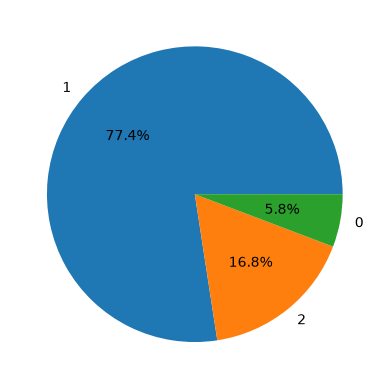

In [5]:
plt.pie(df['class'].value_counts().values,
        labels = df['class'].value_counts().index,
        autopct='%1.1f%%')
plt.show()

# Step 3: Balancing the Dataset

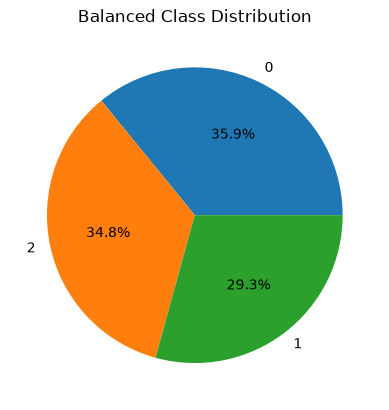

In [6]:
class_0 = df[df['class'] == 0]  # Hate Speech
class_1 = df[df['class'] == 1].sample(n=3500, random_state=42)  # Offensive Language
class_2 = df[df['class'] == 2]  # Neutral

balanced_df = pd.concat([class_0, class_0, class_0, class_1, class_2], axis=0)

# Visualize the balanced distribution
plt.pie(balanced_df['class'].value_counts().values,
        labels=balanced_df['class'].value_counts().index,
        autopct='%1.1f%%')
plt.title("Balanced Class Distribution")
plt.show()

# Step 4: Text Preprocessing

In [7]:
df['tweet'] = df['tweet'].str.lower()

punctuations_list = string.punctuation
def remove_punctuations(text):
    temp = str.maketrans('', '', punctuations_list)
    return text.translate(temp)

df['tweet']= df['tweet'].apply(lambda x: remove_punctuations(x))
df.head()

,class,tweet
0,2,rt mayasolovely as a woman you shouldnt compl...
1,1,rt mleew17 boy dats coldtyga dwn bad for cuff...
2,1,rt urkindofbrand dawg rt 80sbaby4life you eve...
3,1,rt cganderson vivabased she look like a tranny
4,1,rt shenikaroberts the shit you hear about me ...


In [8]:
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]
    return " ".join(words)

balanced_df['tweet'] = balanced_df['tweet'].apply(preprocess_text)

# Step 5: Tokenization and Padding

In [10]:
# Step 5: Tokenization and Padding (PyTorch)
import torch
from collections import Counter
from torch.nn.utils.rnn import pad_sequence

features = balanced_df['tweet']
target = balanced_df['class']
X_train, X_val, Y_train, Y_val = train_test_split(
    features, target, test_size=0.2, random_state=42
)

# One-hot encode the labels (kept consistent with the original notebook).
# Switch to torch.long + CrossEntropyLoss downstream if you prefer class
# indices; this keeps the input shape (n_samples, n_classes) for
# BCEWithLogitsLoss-friendly models.
Y_train = pd.get_dummies(Y_train).values.astype('float32')
Y_val = pd.get_dummies(Y_val).values.astype('float32')

# Tokenization: build a word-index vocab from the training text.
max_words = 5000
max_len = 100
pad_idx = 0
oov_idx = 1

counter = Counter()
for text in X_train:
    counter.update(text.split())

# Reserve 0 for <pad>, 1 for <oov>; assign the rest of the top
# (max_words - 2) tokens their own indices.
vocab = {'<pad>': pad_idx, '<oov>': oov_idx}
for idx, (word, _) in enumerate(counter.most_common(max_words - 2), start=2):
    vocab[word] = idx

def encode(text: str) -> list[int]:
    return [vocab.get(token, oov_idx) for token in text.split()]

# Numericalize and truncate each sequence to max_len.
X_train_seq = [encode(text)[:max_len] for text in X_train]
X_val_seq = [encode(text)[:max_len] for text in X_val]

# Pad to a uniform length so the batch dimension is rectangular.
X_train_t = pad_sequence(
    [torch.tensor(s, dtype=torch.long) for s in X_train_seq],
    batch_first=True,
    padding_value=pad_idx,
)
X_val_t = pad_sequence(
    [torch.tensor(s, dtype=torch.long) for s in X_val_seq],
    batch_first=True,
    padding_value=pad_idx,
)

# All sequences were already truncated to max_len, so the longest in the
# batch is at most max_len; pad_sequence will pad shorter ones up to it.
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
Y_val_t = torch.tensor(Y_val, dtype=torch.float32)

print(f'X_train: {tuple(X_train_t.shape)}, dtype={X_train_t.dtype}')
print(f'X_val:   {tuple(X_val_t.shape)}, dtype={X_val_t.dtype}')
print(f'Y_train: {tuple(Y_train_t.shape)}, dtype={Y_train_t.dtype}')
print(f'Y_val:   {tuple(Y_val_t.shape)}, dtype={Y_val_t.dtype}')
print(f'Vocab size: {len(vocab)} (incl. <pad> and <oov>)')


X_train: (9562, 47), dtype=torch.int64
X_val:   (2391, 31), dtype=torch.int64
Y_train: (9562, 3), dtype=torch.float32
Y_val:   (2391, 3), dtype=torch.float32
Vocab size: 5000 (incl. <pad> and <oov>)


# Step 6: Build the Model
We will implement a Sequential model like LSTM which will contain the following parts:

Embedding Layers to learn a featured vector representations of the input vectors.
Bidirectional LSTM layer to identify useful patterns in the sequence.
We have included BatchNormalization layers to enable stable and fast training and a Dropout layer before the final layer to avoid any possibility of overfitting.
The final layer is the output layer which outputs soft probabilities for the three classes. 

While compiling a model we provide these three essential parameters:

optimizer - This is the method that helps to optimize the cost function by using gradient descent.
loss - The loss function by which we monitor whether the model is improving with training or not.
metrics - This helps to evaluate the model by predicting the training and the validation data.

In [ ]:
import torch
import torch.nn as nn


class HateSpeechClassifier(nn.Module):
    """Bidirectional LSTM classifier with BatchNorm and Dropout.

    Output: raw logits (no softmax). The loss function applies softmax
    internally, and `torch.softmax(model(x), dim=-1)` recovers the
    probabilities at inference time.
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int = 128,
        hidden_dim: int = 64,
        num_classes: int = 3,
        dropout: float = 0.5,
    ) -> None:
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, batch_first=True, bidirectional=True
        )
        self.bn = nn.BatchNorm1d(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        emb = self.embedding(x)              # (batch, max_len, embed_dim)
        out, _ = self.lstm(emb)              # (batch, max_len, hidden_dim * 2)
        pooled = out.mean(dim=1)             # (batch, hidden_dim * 2) - mean pool
        pooled = self.bn(pooled)
        pooled = self.dropout(pooled)
        return self.fc(pooled)               # (batch, num_classes) - raw logits


model = HateSpeechClassifier(vocab_size=len(vocab), num_classes=3)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

# Optimizer, loss, and metrics ("compile" step in PyTorch is split
# across the optimizer and loss function below).
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# CrossEntropyLoss expects class indices of shape (batch,). If you keep
# Y_train_t / Y_val_t as one-hot float32, swap to `nn.BCEWithLogitsLoss()`
# and pass `loss_fn(logits, Y_train_t)` directly.
loss_fn = nn.CrossEntropyLoss()


def accuracy(logits: torch.Tensor, targets: torch.Tensor) -> float:
    """Top-1 accuracy. Accepts one-hot (n, k) or index (n,) targets."""
    if targets.ndim == 2:
        targets = targets.argmax(dim=1)
    return (logits.argmax(dim=1) == targets).float().mean().item()


print(f"Optimizer: {optimizer.__class__.__name__} (lr={optimizer.defaults['lr']})")
print(f"Loss:      {loss_fn.__class__.__name__}")
print("Metric:    accuracy")


# Step 7: Training the Model

Standard PyTorch training loop over `X_train_t` / `Y_train_t`,
validating on `X_val_t` / `Y_val_t` each epoch. Tracks train and val
loss + accuracy in `history` for the next step.


In [12]:
from torch.utils.data import DataLoader, TensorDataset

# ---- DataLoaders ----------------------------------------------------------
batch_size = 64
train_ds = TensorDataset(X_train_t, Y_train_t)
val_ds = TensorDataset(X_val_t, Y_val_t)
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=batch_size)

# ---- Device --------------------------------------------------------------
# CPU for M1; swap to 'cuda' when a GPU is available.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# ---- Training loop -------------------------------------------------------
epochs = 10
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
}

for epoch in range(1, epochs + 1):
    # ---- train ----
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0
    for xb, yb in train_dl:
        xb = xb.to(device)
        yb = yb.to(device)
        # CrossEntropyLoss expects class indices; flatten one-hot if needed.
        yb_idx = yb.argmax(dim=1) if yb.ndim == 2 else yb

        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb_idx)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * xb.size(0)
        train_correct += (logits.argmax(dim=1) == yb_idx).sum().item()
        train_total += xb.size(0)

    # ---- validate ----
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb = xb.to(device)
            yb = yb.to(device)
            yb_idx = yb.argmax(dim=1) if yb.ndim == 2 else yb

            logits = model(xb)
            loss = loss_fn(logits, yb_idx)

            val_loss_sum += loss.item() * xb.size(0)
            val_correct += (logits.argmax(dim=1) == yb_idx).sum().item()
            val_total += xb.size(0)

    train_loss = train_loss_sum / train_total
    val_loss = val_loss_sum / val_total
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(
        f"Epoch {epoch:>2d}/{epochs} | "
        f"train loss {train_loss:.4f} | train acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f} | val acc {val_acc:.4f}"
    )


Epoch  1/10 | train loss 0.7784 | train acc 0.6807 | val loss 0.6976 | val acc 0.7327
Epoch  2/10 | train loss 0.5457 | train acc 0.7896 | val loss 0.5527 | val acc 0.7976
Epoch  3/10 | train loss 0.4237 | train acc 0.8352 | val loss 0.4920 | val acc 0.8281
Epoch  4/10 | train loss 0.3173 | train acc 0.8878 | val loss 0.5167 | val acc 0.8432
Epoch  5/10 | train loss 0.2414 | train acc 0.9143 | val loss 0.5578 | val acc 0.8143
Epoch  6/10 | train loss 0.1644 | train acc 0.9430 | val loss 0.6025 | val acc 0.8532
Epoch  7/10 | train loss 0.1176 | train acc 0.9616 | val loss 0.4426 | val acc 0.8766
Epoch  8/10 | train loss 0.0946 | train acc 0.9694 | val loss 0.7785 | val acc 0.8356
Epoch  9/10 | train loss 0.0746 | train acc 0.9765 | val loss 0.4407 | val acc 0.8854
Epoch 10/10 | train loss 0.0767 | train acc 0.9743 | val loss 0.6840 | val acc 0.8570


# Step 8: Evaluating the Model
Visualize the training progress and evaluate the modelâ€™s performance.

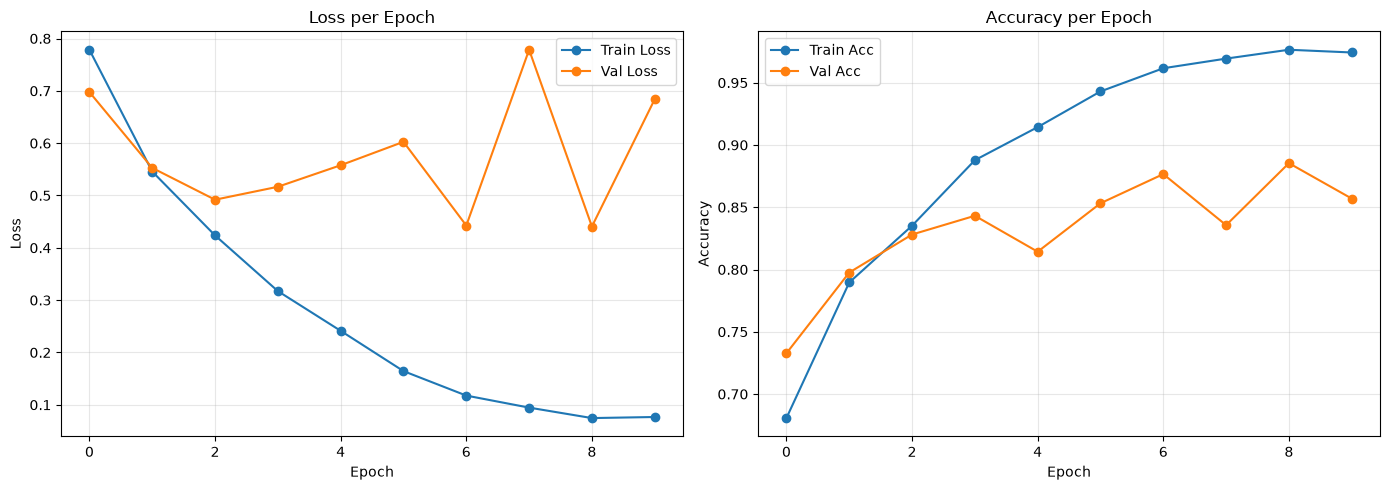

Classification Report (validation set):
                    precision    recall  f1-score   support

       hate_speech     0.7936    0.9895    0.8808       855
offensive_language     0.8858    0.7514    0.8131       712
           neither     0.9265    0.8107    0.8647       824

          accuracy                         0.8570      2391
         macro avg     0.8686    0.8505    0.8529      2391
      weighted avg     0.8668    0.8570    0.8551      2391

Macro F1: 0.8529  (target: >= 0.85)


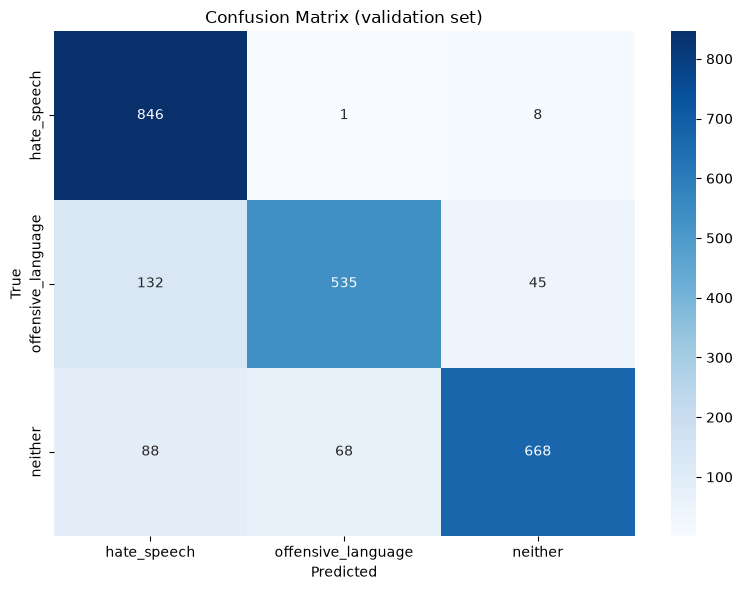

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Class label mapping (matches the dataset's 0/1/2 ints from the EDA).
class_names = ['hate_speech', 'offensive_language', 'neither']

# ---- Training curves -----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='o')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(history['val_acc'], label='Val Acc', marker='o')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Final evaluation on the validation set -----------------------------
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for xb, yb in val_dl:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        labels = yb.argmax(dim=1).cpu().numpy() if yb.ndim == 2 else yb.cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

print('Classification Report (validation set):')
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# Macro F1 is the success metric from issue #1 (target: >= 0.85).
macro_f1 = f1_score(all_labels, all_preds, average='macro')
print(f'Macro F1: {macro_f1:.4f}  (target: >= 0.85)')

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sb.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
)
plt.title('Confusion Matrix (validation set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()


# Step 9: Test Accuracy

In [16]:
# Step 9: Test Accuracy
# The notebook doesn't split out a separate test set, so the held-out
# accuracy reported here is on the validation split used throughout.
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for xb, yb in val_dl:
        xb = xb.to(device)
        yb = yb.to(device)
        # CrossEntropyLoss wants class indices; flatten one-hot if needed.
        yb_idx = yb.argmax(dim=1) if yb.ndim == 2 else yb
        logits = model(xb)
        preds = logits.argmax(dim=1)
        correct += (preds == yb_idx).sum().item()
        total += xb.size(0)

test_acc = correct / total
print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 0.8570
